# Notebook 1 — Hat Functions and Interpolation in 1D

This notebook introduces the **core geometric idea** behind the finite element method (FEM):

- divide the interval into small **elements**
- define simple basis functions on the mesh
- approximate the solution as a weighted sum of basis functions

We start with **piecewise linear hat functions** in 1D.

We will work on the interval $[0,1]$.

## 1. Mesh and nodes

Suppose we divide the interval into equal subintervals.  
The mesh nodes are

$$
x_0, x_1, \dots, x_n
$$

and the elements are the intervals

$$
[x_0,x_1], [x_1,x_2], \dots, [x_{n-1},x_n].
$$

For linear FEM, each basis function is associated with one node.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Uniform 1D mesh
n_elements = 6
x_nodes = np.linspace(0.0, 1.0, n_elements + 1)
x_nodes

array([0.        , 0.16666667, 0.33333333, 0.5       , 0.66666667,
       0.83333333, 1.        ])

## 2. Piecewise linear hat functions

The basis function $\phi_i(x)$ is equal to:

- $1$ at node $x_i$
- $0$ at all other nodes
- linear between neighboring nodes

So each basis function looks like a **hat**.

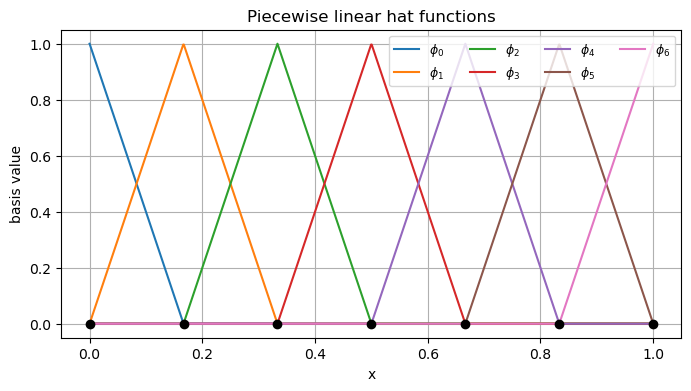

In [2]:
def hat_function(x, nodes, i):
    '''
    Evaluate the i-th piecewise linear hat function on a 1D mesh.
    '''
    x = np.asarray(x)
    phi = np.zeros_like(x, dtype=float)

    # Left interval [x_{i-1}, x_i]
    if i > 0:
        xl = nodes[i - 1]
        xm = nodes[i]
        mask = (x >= xl) & (x <= xm)
        phi[mask] = (x[mask] - xl) / (xm - xl)

    # Right interval [x_i, x_{i+1}]
    if i < len(nodes) - 1:
        xm = nodes[i]
        xr = nodes[i + 1]
        mask = (x >= xm) & (x <= xr)
        phi[mask] = (xr - x[mask]) / (xr - xm)

    return phi

xx = np.linspace(0, 1, 1000)

plt.figure(figsize=(8, 4))
for i in range(len(x_nodes)):
    plt.plot(xx, hat_function(xx, x_nodes, i), label=fr"$\phi_{i}$")
plt.plot(x_nodes, np.zeros_like(x_nodes), "ko")
plt.xlabel("x")
plt.ylabel("basis value")
plt.title("Piecewise linear hat functions")
plt.grid(True)
plt.legend(ncol=4, fontsize=9)
plt.show()

## 3. Key properties of the basis

The hat functions satisfy:

### Interpolation property
At the nodes,

$$
\phi_i(x_j) =
\begin{cases}
1, & i=j, \\
0, & i\neq j.
\end{cases}
$$

### Local support
Each $\phi_i(x)$ is nonzero only on the elements touching node $i$.

### Partition of unity
At any point $x$ inside the domain,

$$
\sum_i \phi_i(x) = 1.
$$

In [3]:
# Check the interpolation property numerically
Phi_at_nodes = np.zeros((len(x_nodes), len(x_nodes)))
for i in range(len(x_nodes)):
    Phi_at_nodes[:, i] = hat_function(x_nodes, x_nodes, i)

Phi_at_nodes

array([[1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.]])

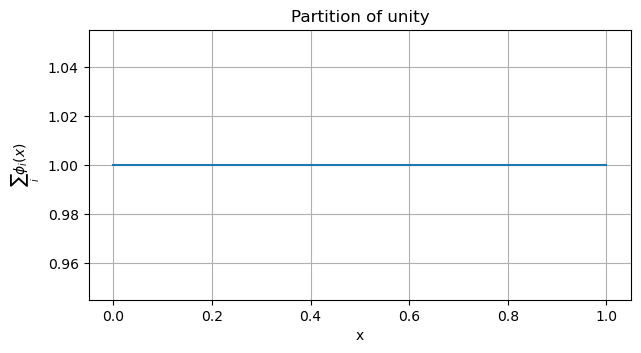

Minimum of sum: 0.9999999999999999
Maximum of sum: 1.0


In [4]:
# Check the partition of unity
phi_sum = np.zeros_like(xx)
for i in range(len(x_nodes)):
    phi_sum += hat_function(xx, x_nodes, i)

plt.figure(figsize=(7, 3.5))
plt.plot(xx, phi_sum)
plt.xlabel("x")
plt.ylabel(r"$\sum_i \phi_i(x)$")
plt.title("Partition of unity")
plt.grid(True)
plt.show()

print("Minimum of sum:", phi_sum.min())
print("Maximum of sum:", phi_sum.max())

## 4. Interpolating a function

Suppose we know a function $f(x)$ at the mesh nodes.  
Its linear finite-element interpolant is

$$
I_h f(x) = \sum_{i=0}^{n} f(x_i)\,\phi_i(x).
$$

This means that the nodal values become the coefficients of the basis functions.

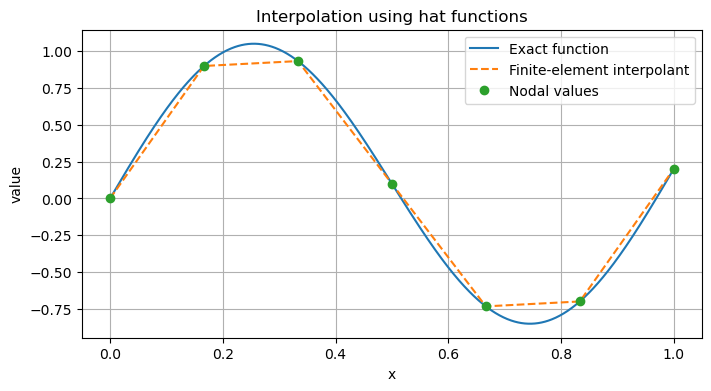

In [5]:
def f(x):
    return np.sin(2*np.pi*x) + 0.2*x

f_nodes = f(x_nodes)

interp = np.zeros_like(xx)
for i in range(len(x_nodes)):
    interp += f_nodes[i] * hat_function(xx, x_nodes, i)

plt.figure(figsize=(8, 4))
plt.plot(xx, f(xx), label="Exact function")
plt.plot(xx, interp, "--", label="Finite-element interpolant")
plt.plot(x_nodes, f_nodes, "o", label="Nodal values")
plt.xlabel("x")
plt.ylabel("value")
plt.title("Interpolation using hat functions")
plt.grid(True)
plt.legend()
plt.show()

## 5. What this means for FEM

In finite elements, we do not usually solve directly for the value of the unknown everywhere.

Instead, we write the approximation as

$$
u_h(x) = \sum_{i=0}^{n} U_i \phi_i(x),
$$

where:

- $\phi_i(x)$ are known basis functions
- $U_i$ are the unknown nodal coefficients

So FEM turns a differential equation into a problem of finding the coefficients $U_i$.

## 6. Exercise ideas

Try the following:

1. change the number of elements
2. change the function $f(x)$
3. plot a single hat function, for example $\phi_3(x)$
4. verify that the interpolant matches the exact function at the nodes

In [6]:
# A small check: the interpolant should match the exact function at the nodes.
interp_at_nodes = np.zeros_like(x_nodes)
for i in range(len(x_nodes)):
    interp_at_nodes += f_nodes[i] * hat_function(x_nodes, x_nodes, i)

print("f(x_nodes)        =", f_nodes)
print("interpolant nodes =", interp_at_nodes)
print("difference        =", interp_at_nodes - f_nodes)

f(x_nodes)        = [ 0.          0.89935874  0.93269207  0.1        -0.73269207 -0.69935874
  0.2       ]
interpolant nodes = [ 0.          0.89935874  0.93269207  0.1        -0.73269207 -0.69935874
  0.2       ]
difference        = [0. 0. 0. 0. 0. 0. 0.]


## Summary

In this notebook, we learned that:

- the domain is divided into elements
- each node has a hat-shaped basis function
- the approximate solution is a linear combination of those basis functions
- nodal values become the unknown coefficients

This is the first building block of the finite element method.